In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
plt.rcParams['font.family'] = ['Microsoft YaHei','SimHei','sans-serif']

In [19]:
shop=pd.read_excel('shop_new2.xlsx',None)
order=shop['订单信息']
order

,订单ID,客户ID,订单状态,优惠类型
0,47739,5245,1,0
1,341269,5245,0,0
2,32690,5254,1,0
3,45641,5254,1,0
4,66116,5254,1,0
...,...,...,...,...
29145,446758,169934,1,1
29146,446759,169934,1,0
29147,447165,169976,0,1
29148,447274,169976,0,1


In [20]:
all=pd.crosstab(
    order['客户ID'],
    order['优惠类型']
)
all

优惠类型,0,1
客户ID,,
5245,2,0
5254,9,1
5286,7,1
5292,4,5
5474,1,1
...,...,...
169699,1,1
169815,0,1
169832,0,1


In [21]:
p=all[all[1]/(all[0]+all[1])>=0.75].index.values
p

array([  5560,   5580,   5723, ..., 169815, 169832, 169976], dtype=int64)

In [22]:
customer=shop['顾客信息']
customer

,客户ID,登陆次数,经验值,订单数
0,5245,55,206,1
1,5254,69,428,9
2,5286,57,280,2
3,5292,184,643,6
4,5474,71,61,2
...,...,...,...,...
2995,169699,20,153,2
2996,169815,13,57,1
2997,169832,12,62,1
2998,169934,14,68,2


In [23]:
customer=customer.set_index('客户ID')
customer

,登陆次数,经验值,订单数
客户ID,,,
5245,55,206,1
5254,69,428,9
5286,57,280,2
5292,184,643,6
5474,71,61,2
...,...,...,...
169699,20,153,2
169815,13,57,1
169832,12,62,1


In [24]:
customer['客户类型']=1

In [25]:
customer

,登陆次数,经验值,订单数,客户类型
客户ID,,,,
5245,55,206,1,1
5254,69,428,9,1
5286,57,280,2,1
5292,184,643,6,1
5474,71,61,2,1
...,...,...,...,...
169699,20,153,2,1
169815,13,57,1,1
169832,12,62,1,1


In [26]:
customer.loc[p,'客户类型']=0
customer

,登陆次数,经验值,订单数,客户类型
客户ID,,,,
5245,55,206,1,1
5254,69,428,9,1
5286,57,280,2,1
5292,184,643,6,1
5474,71,61,2,1
...,...,...,...,...
169699,20,153,2,1
169815,13,57,1,0
169832,12,62,1,0


<Axes: ylabel='count'>

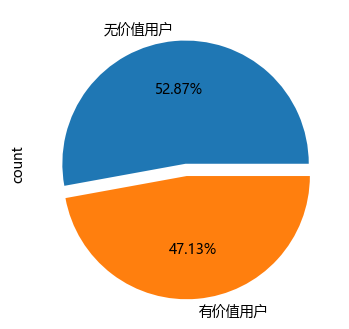

In [32]:
customer['客户类型'].value_counts().rename(index={0:'无价值用户',1:'有价值用户'}).plot.pie(
    figsize=(6,4),
    autopct='%1.2f%%',
    explode=(0,0.1)
)

<Axes: xlabel='客户类型'>

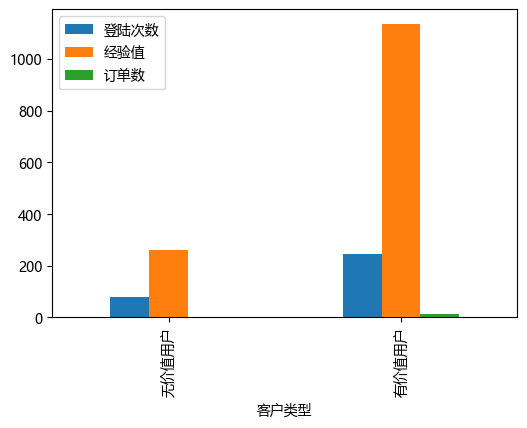

In [36]:
customer.groupby('客户类型').mean().rename({0:"无价值用户",1:'有价值用户'}).plot.bar(
    figsize=(6,4)
)